# tap.808.* — calibration against a real TR-808 (plan §7.2)

The `tr808_*.h` kernels are **circuit-informed** models; this notebook is the
plan's §7.2 reality check: every voice measured against samples of a **real
TR-808** and the deltas quantified per knob position. It reproduces the
calibration pass whose results live as *§7.2 calibration* notes in each kernel
header — rerun it after any kernel change to see where the model stands.

**The reference:** Michael Fischer's *Technopolis* TR-808 Sound Sample Set 1.0.0
(1994) — distributed free by its author, still hosted at
[machines.hyperreal.org](http://machines.hyperreal.org/manufacturers/Roland/TR-808/samples/).
It was recorded from a real unit (serial no. 103852) through the **individual
outs**, each voice's level at maximum, 16-bit/44.1 kHz — and, crucially, the
**knob positions are encoded in the filenames** on a 0/2.5/5/7.5/10 dial grid
(e.g. `BD2575.WAV` = bass drum, TONE 2.5, DECAY 7.5). That upgrades this from a
listening check to a quantitative per-knob-cell comparison: 116 reference
samples across the family.

**Our side:** the kernel repo's `tools/render/tr808_render` re-renders the exact
grid via its repeatable `--set NAME VALUE` knob arguments — the same shipping
code the Max externals compile, no Python re-implementation. Identical
measurements run on both sides: spectral-peak fundamental (parabolic
interpolation), −40 dB decay time, and power spectral centroid.

One caveat to hold while reading the tables: this is *one unit* (and Fischer's
hand-set dial positions). ±20% is honest unit/dial territory — the family models
that spread deliberately (`@tolerance`/`@seed`). The calibration siding with the
measured unit over the service-manual chart is documented per header.

In [1]:
import json
import pathlib
import shutil
import struct
import subprocess
import sys
import urllib.request
import zipfile

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

KERNEL = pathlib.Path.cwd().resolve().parent
BUILD = KERNEL / "build"
RENDER = BUILD / "tools" / "render" / "tr808_render"

# Build the render tool if missing (same convention as taptools_py's C ABI build).
if not RENDER.exists():
    if not BUILD.exists():
        subprocess.run(["cmake", "-S", str(KERNEL), "-B", str(BUILD),
                        "-DCMAKE_BUILD_TYPE=Release"], check=True)
    subprocess.run(["cmake", "--build", str(BUILD), "-j", "--target", "tr808_render"],
                   check=True)
print("render tool:", RENDER)

render tool: /home/user/TapTools/build/tools/render/tr808_render


## 1. The reference set

Downloaded once and cached in `notebooks/_tr808_ref/` (gitignored). ~7.6 MB.

In [2]:
REF_URL = "http://machines.hyperreal.org/manufacturers/Roland/TR-808/samples/TR808all.zip"
REF_DIR = pathlib.Path("_tr808_ref")
REF_WAVS = REF_DIR / "TR808WAV"

if not REF_WAVS.exists():
    REF_DIR.mkdir(exist_ok=True)
    zpath = REF_DIR / "TR808all.zip"
    if not zpath.exists():
        print("downloading", REF_URL)
        urllib.request.urlretrieve(REF_URL, zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(REF_DIR)

ref_files = {p.stem.upper(): p for p in REF_WAVS.rglob("*.WAV")}
print(len(ref_files), "reference samples")

116 reference samples


## 2. Rendering our side of the grid

The filename convention maps dial positions to our 0..1 attributes directly
(assuming linear dials — Fischer's own caveat). `--set` warns on any knob-name
typo, so the map below can't silently render defaults.

In [3]:
OUR_DIR = pathlib.Path("_tr808_ours")
DIAL = {"00": 0.0, "25": 0.25, "50": 0.5, "75": 0.75, "10": 1.0}

def hit(voice, out_name, sets):
    args = [str(RENDER), "--hit", voice, "1.0", str(OUR_DIR)]
    for k, v in sets:
        args += ["--set", k, str(v)]
    subprocess.run(args, check=True, capture_output=True)
    (OUR_DIR / f"tr808_{voice}_hit.wav").rename(OUR_DIR / f"{out_name}.wav")

if OUR_DIR.exists():
    shutil.rmtree(OUR_DIR)
OUR_DIR.mkdir()

for a, va in DIAL.items():
    for b, vb in DIAL.items():
        hit("kick", f"BD{a}{b}", [("tone", va), ("decay", vb)])
        hit("snare", f"SD{a}{b}", [("tone", va), ("snappy", vb)])
        hit("cymbal", f"CY{a}{b}", [("tone", va), ("decay", vb)])
    hit("openhat", f"OH{a}", [("decay", va)])
    for size, tom_code, conga_code in [(0, "LT", "LC"), (1, "MT", "MC"), (2, "HT", "HC")]:
        hit("tom", f"{tom_code}{a}", [("size", size), ("tuning", va)])
        hit("conga", f"{conga_code}{a}", [("size", size), ("tuning", va)])
hit("hat", "CH", [])
hit("rimshot", "RS", [])
hit("claves", "CL", [])
hit("clap", "CP", [])
hit("maracas", "MA", [])
hit("cowbell", "CB", [])

our_files = {p.stem.upper(): p for p in OUR_DIR.glob("*.wav")}
print(len(our_files), "renders")
assert set(our_files) == set(ref_files)

116 renders


## 3. Measurements

Identical code runs on both sides (the reference is 16-bit/44.1 kHz PCM, ours
32-bit float/48 kHz — each is measured at its own rate, so no resampling bias):

- **t40** — time until the waveform last exceeds −40 dB of its peak.
- **f0** — spectral-peak fundamental, Hann window + parabolic bin interpolation.
- **centroid** — power spectral centroid above a floor frequency (noise voices).

Rows where a metric is meaningless are skipped (e.g. a noise centroid at
`snappy 0`, where there is no noise to measure — on either side it just reads
numerical floor).

In [4]:
def load_wav(path):
    """Minimal RIFF reader for PCM16 and float32 mono; trims to onset."""
    b = pathlib.Path(path).read_bytes()
    i = b.find(b"fmt ")
    fmt, _ch, sr = struct.unpack("<HHI", b[i + 8:i + 16])
    bits = struct.unpack("<H", b[i + 22:i + 24])[0]
    i = b.find(b"data")
    n = struct.unpack("<I", b[i + 4:i + 8])[0]
    raw = b[i + 8:i + 8 + n]
    if fmt == 1 and bits == 16:
        x = np.frombuffer(raw[: len(raw) // 2 * 2], dtype="<i2").astype(np.float64) / 32768.0
    elif fmt == 3 and bits == 32:
        x = np.frombuffer(raw[: len(raw) // 4 * 4], dtype="<f4").astype(np.float64)
    else:
        raise ValueError(f"unhandled wav format {fmt}/{bits}")
    p = np.abs(x).max()
    if p > 0:
        onset = np.argmax(np.abs(x) > 0.02 * p)
        x = x[max(0, onset - int(0.001 * sr)):]
    return sr, x

def t40_ms(sr, x):
    above = np.nonzero(np.abs(x) > 0.01 * np.abs(x).max())[0]
    return 1000.0 * above[-1] / sr if len(above) else 0.0

def f0_hz(sr, x, lo, hi):
    if len(x) < 64:
        return np.nan
    n = int(2 ** np.ceil(np.log2(len(x) * 4)))
    s = np.abs(np.fft.rfft(x * np.hanning(len(x)), n))
    f = np.fft.rfftfreq(n, 1.0 / sr)
    k = int(np.argmax(s * ((f >= lo) & (f <= hi))))
    d = 0.0
    if 0 < k < len(s) - 1 and s[k] > 0:
        d = 0.5 * (s[k - 1] - s[k + 1]) / (s[k - 1] - 2 * s[k] + s[k + 1])
    return f[k] + d * (f[1] - f[0])

def centroid_hz(sr, x, lo):
    n = int(2 ** np.ceil(np.log2(max(len(x), 64))))
    s = np.abs(np.fft.rfft(x, n)) ** 2
    f = np.fft.rfftfreq(n, 1.0 / sr)
    m = f >= lo
    return float((f[m] * s[m]).sum() / s[m].sum())

KIND = {"BD": "kick", "SD": "snare", "CY": "noise", "OH": "noise", "CH": "noise",
        "CP": "noise", "MA": "noise", "LT": "tonal", "MT": "tonal", "HT": "tonal",
        "LC": "tonal", "MC": "tonal", "HC": "tonal", "RS": "tonal", "CL": "tonal",
        "CB": "tonal"}

def measure(path, kind, code):
    sr, x = load_wav(path)
    row = {"t40": t40_ms(sr, x)}
    if kind == "tonal":
        row["f0"] = f0_hz(sr, x, 60, 3000)
    elif kind == "kick":
        row["f0"] = f0_hz(sr, x, 25, 200)
    elif kind == "snare":
        row["f0"] = f0_hz(sr, x[: int(0.06 * sr)], 100, 500)
        if code[4:] != "00":                      # snappy 0: nothing to measure
            row["centroid"] = centroid_hz(sr, x, 1000)
    else:
        row["centroid"] = centroid_hz(sr, x, 500)
    return row

results = {}
for c in sorted(ref_files):
    kind = KIND[c[:2]]
    results[c] = (measure(ref_files[c], kind, c), measure(our_files[c], kind, c))
print(len(results), "cells measured")

116 cells measured


## 4. Per-voice delta tables

`Δ` is ours relative to the reference. The per-voice medians are the headline;
single-cell outliers are usually dial/edit noise in a 1994 hand-made set.

In [5]:
def table(prefix, metrics):
    rows = [(c, r, o) for c, (r, o) in results.items() if c.startswith(prefix)]
    print(f"== {prefix} ==")
    deltas = {m: [] for m in metrics}
    for c, r, o in sorted(rows):
        parts = [f"{c:7s}"]
        for m in metrics:
            if m in r and m in o and np.isfinite(r[m]) and np.isfinite(o[m]) and r[m]:
                d = (o[m] / r[m] - 1) * 100
                deltas[m].append(d)
                parts.append(f"{m} {r[m]:7.1f} -> {o[m]:7.1f} ({d:+6.1f}%)")
        print("  ".join(parts))
    for m in metrics:
        if deltas[m]:
            print(f"  median |d| {m}: {np.median(np.abs(deltas[m])):.1f}%")
    print()

table("BD", ["f0", "t40"])
table("SD", ["f0", "t40", "centroid"])
for p in ["LT", "MT", "HT", "LC", "MC", "HC"]:
    table(p, ["f0", "t40"])
table("RS", ["f0", "t40"]); table("CL", ["f0", "t40"]); table("CB", ["f0", "t40"])
table("CP", ["centroid", "t40"]); table("MA", ["centroid", "t40"])
table("CH", ["centroid", "t40"]); table("OH", ["centroid", "t40"])
table("CY", ["centroid", "t40"])

== BD ==
BD0000   f0    49.6 ->    48.5 (  -2.4%)  t40    72.3 ->    68.6 (  -5.1%)
BD0010   f0    49.7 ->    49.5 (  -0.3%)  t40  2361.7 ->  2421.0 (  +2.5%)
BD0025   f0    49.7 ->    49.4 (  -0.5%)  t40   237.6 ->   295.7 ( +24.4%)
BD0050   f0    49.7 ->    49.5 (  -0.4%)  t40   617.5 ->   635.1 (  +2.9%)
BD0075   f0    49.7 ->    49.5 (  -0.4%)  t40  1248.5 ->  1213.9 (  -2.8%)
BD1000   f0    49.6 ->    48.4 (  -2.4%)  t40    71.3 ->    67.4 (  -5.5%)
BD1010   f0    49.7 ->    49.5 (  -0.3%)  t40  2361.4 ->  2380.1 (  +0.8%)
BD1025   f0    49.7 ->    49.4 (  -0.5%)  t40   237.2 ->   285.8 ( +20.5%)
BD1050   f0    49.6 ->    49.5 (  -0.4%)  t40   786.6 ->   624.5 ( -20.6%)
BD1075   f0    49.6 ->    49.5 (  -0.4%)  t40  1288.4 ->  1193.2 (  -7.4%)
BD2500   f0    49.6 ->    48.4 (  -2.4%)  t40    72.1 ->    68.5 (  -5.1%)
BD2510   f0    49.7 ->    49.5 (  -0.3%)  t40  2361.5 ->  2410.8 (  +2.1%)
BD2525   f0    49.7 ->    49.4 (  -0.5%)  t40   218.4 ->   295.4 ( +35.2%)
BD2550   f0    4

## 5. Overlays — a few cells worth looking at

Spectra are of the whole hit (Hann), normalized to their own peaks so shape is
the only variable; envelopes are peak-tracked in dB.

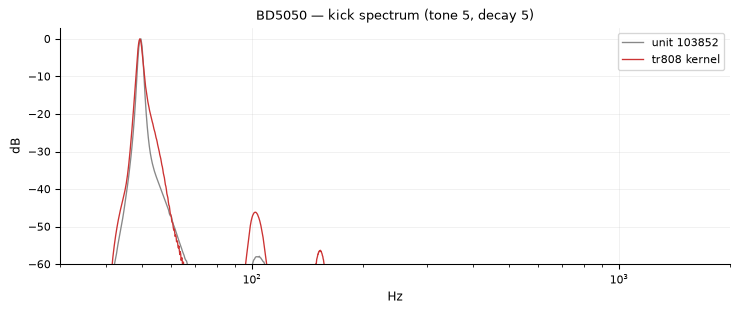

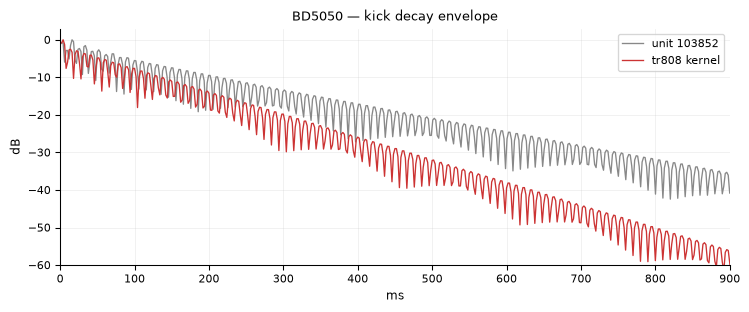

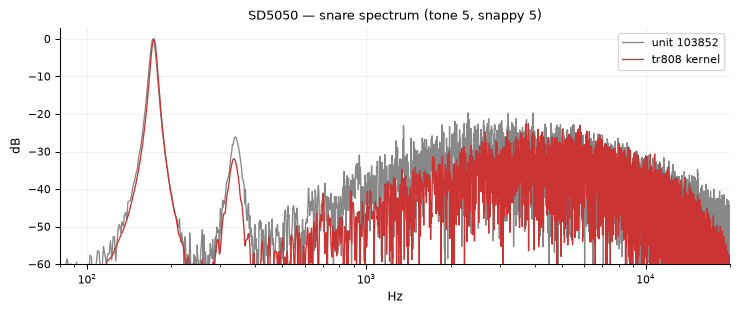

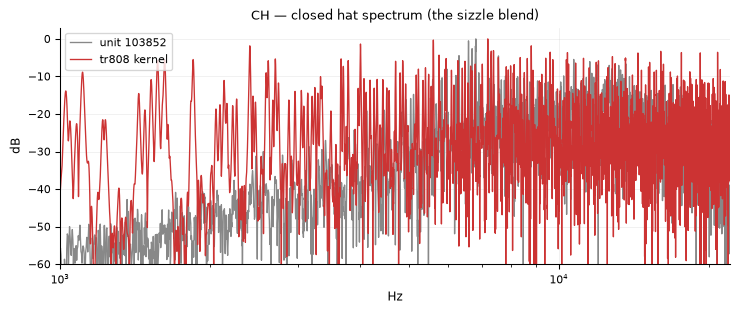

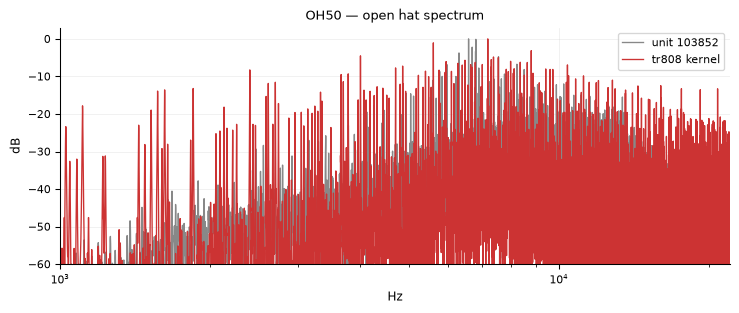

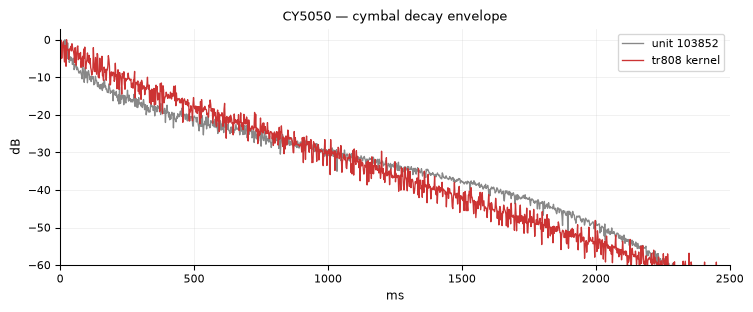

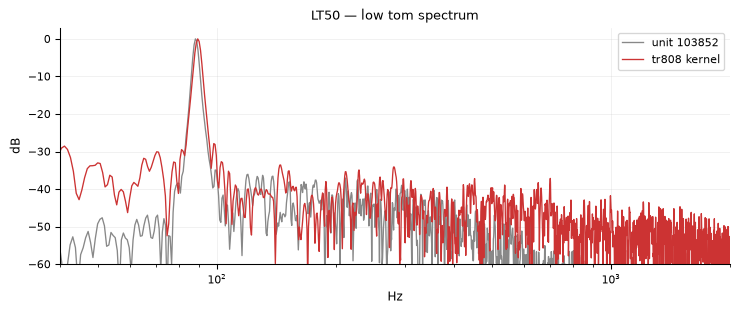

In [6]:
def spectrum_db(sr, x):
    n = int(2 ** np.ceil(np.log2(max(len(x), 64))))
    s = np.abs(np.fft.rfft(x * np.hanning(len(x)), n))
    f = np.fft.rfftfreq(n, 1.0 / sr)
    db = 20 * np.log10(s / s.max() + 1e-9)
    return f, db

def env_db(sr, x, hop_ms=2.0):
    hop = max(1, int(hop_ms * sr / 1000))
    seg = x[: len(x) // hop * hop].reshape(-1, hop)
    e = np.abs(seg).max(axis=1)
    t = np.arange(len(e)) * hop / sr * 1000
    return t, 20 * np.log10(e / e.max() + 1e-9)

def overlay(code, mode, xlim, title):
    (rf, rx), (of, ox) = load_wav(ref_files[code]), load_wav(our_files[code])
    fig, ax = plt.subplots()
    fn = spectrum_db if mode == "spec" else env_db
    for (sr, x), label, color in [((rf, rx), "unit 103852", "#888"),
                                  ((of, ox), "tr808 kernel", "#c33")]:
        a, b = fn(sr, x)
        ax.plot(a, b, label=label, color=color, lw=1)
    ax.set(xlim=xlim, ylim=(-60, 3), title=title,
           xlabel="Hz" if mode == "spec" else "ms", ylabel="dB")
    if mode == "spec":
        ax.set_xscale("log")
    ax.legend()
    plt.show()

overlay("BD5050", "spec", (30, 2000), "BD5050 — kick spectrum (tone 5, decay 5)")
overlay("BD5050", "env", (0, 900), "BD5050 — kick decay envelope")
overlay("SD5050", "spec", (80, 20000), "SD5050 — snare spectrum (tone 5, snappy 5)")
overlay("CH", "spec", (1000, 22000), "CH — closed hat spectrum (the sizzle blend)")
overlay("OH50", "spec", (1000, 22000), "OH50 — open hat spectrum")
overlay("CY5050", "env", (0, 2500), "CY5050 — cymbal decay envelope")
overlay("LT50", "spec", (40, 2000), "LT50 — low tom spectrum")

## 6. What the calibration changed, and what remains

Measured first, then fixed (full numbers in each kernel header's *§7.2
calibration* note):

- **Pitches were already right nearly everywhere** — kick within 2.4% at every
  cell, snare within 1.2% (including the tone-max flip to the ~336 Hz mode),
  toms/congas/cowbell/claves within ~4%. The bridged-T component math and the
  chart tuning spans survive contact with a real unit.
- **Decay classes re-fit**: tom/conga/cowbell/clap −40 dB tails were roughly
  half the measured unit's (the chart's figures read at a hotter reference
  level); the cymbal's span became the measured 0.65–2.7 s.
- **Noise voicings re-fit**: the snare's snappy band-limited (the schematic
  high-pass alone left it white to Nyquist) with a fitted VR9 dial law; the
  maracas band-limited; the rimshot re-voiced low-dominant (the real RS peaks
  at ~455 Hz).
- **The hats' sizzle blend**: the real closed hat reads ~10.9 kHz centroid —
  far above what the shared 7.1 kHz band-pass can produce. Blending the bank's
  raw upper harmonics per path (heavily into CH, lightly into OH) lands both
  centroids within ~1.3%, with the decay classes untouched.

Remaining honest residuals: snare noise centroid +12–20%; kick mid-dial decay
±30% (dial taper); cymbal tone-max centroid ~−15%. All are inside single-unit /
hand-set-dial territory. The DAFx-14 paper's gen~ kick remains available as an
independent cross-check.